# Importing Libraries

In [1]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [1]:
%pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [6]:
# ============================================================
# STEP 1: IMPORT REQUIRED LIBRARIES
# ============================================================
import re
import string
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Download NLTK resources
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

print("All libraries imported successfully.")

All libraries imported successfully.


In [7]:
# ============================================================
# STEP 2: LOAD DATASET & DEFINE COLUMNS
# ============================================================
DATASET_PATH = r"D:\Twitter\twitter.csv"  # Update path if needed
df = pd.read_csv(DATASET_PATH)

TEXT_COLUMN = "tweet"
TARGET_COLUMN = "label"

# Map numerical labels to human-readable sentiment categories
LABEL_MAPPING = {
    0: "Non-Hate / Positive-Neutral",
    1: "Hate Speech / Negative"
}
df["sentiment_desc"] = df[TARGET_COLUMN].map(LABEL_MAPPING)

print("=" * 60)
print(f"Dataset Loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("=" * 60)
display(df.head())

Dataset Loaded: 31962 rows, 4 columns


,id,label,tweet,sentiment_desc
0,1,0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,Non-Hate / Positive-Neutral
1,2,0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,Non-Hate / Positive-Neutral
2,3,0,bihday your majesty,Non-Hate / Positive-Neutral
3,4,0,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦,Non-Hate / Positive-Neutral
4,5,0,factsguide: society now #motivation,Non-Hate / Positive-Neutral


Sentiment Class Distribution:


,Count,Percentage (%),Category
label,,,
0,29720,92.99,Non-Hate / Positive-Neutral
1,2242,7.01,Hate Speech / Negative


C:\Users\Swapna\AppData\Local\Temp\ipykernel_18688\913258557.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=TARGET_COLUMN, palette="viridis")


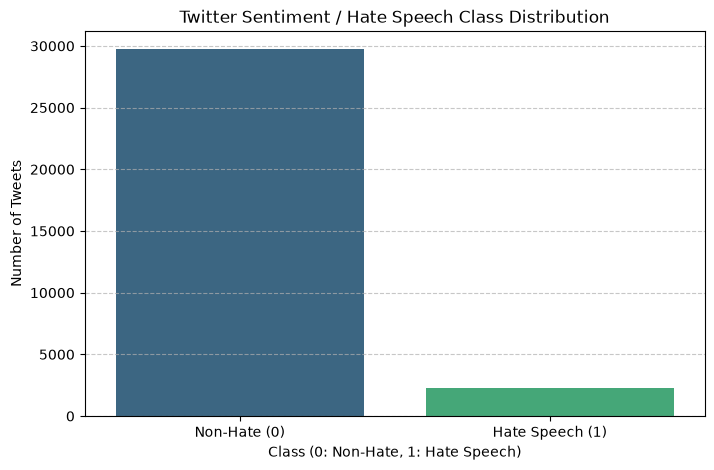

In [8]:
# ============================================================
# STEP 3: CLASS DISTRIBUTION ANALYSIS
# ============================================================
print("Sentiment Class Distribution:")
distribution_df = pd.DataFrame({
    "Count": df[TARGET_COLUMN].value_counts(),
    "Percentage (%)": (df[TARGET_COLUMN].value_counts(normalize=True) * 100).round(2),
    "Category": df[TARGET_COLUMN].map(LABEL_MAPPING).value_counts().index
})
display(distribution_df)

# Visualize Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COLUMN, palette="viridis")
plt.title("Twitter Sentiment / Hate Speech Class Distribution")
plt.xlabel("Class (0: Non-Hate, 1: Hate Speech)")
plt.ylabel("Number of Tweets")
plt.xticks(ticks=[0, 1], labels=["Non-Hate (0)", "Hate Speech (1)"])
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [9]:
# ============================================================
# STEP 4: TWITTER TEXT PREPROCESSING
# ============================================================
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words("english"))
# Keep sentiment-bearing words if needed
stop_words.discard("not")
stop_words.discard("no")

def clean_tweet(text):
    if not isinstance(text, str):
        return ""
    
    # 1. Lowercase text
    text = text.lower()
    
    # 2. Remove Twitter handles (@user)
    text = re.sub(r"@\w+", "", text)
    
    # 3. Remove URLs/Web links
    text = re.sub(r"http\S+|www\S+|https\S+", "", text, flags=re.MULTILINE)
    
    # 4. Remove broken Unicode/HTML artifacts (e.g., ðŸ˜, &amp;)
    text = re.sub(r"&[a-z]+;", "", text)
    text = text.encode("ascii", "ignore").decode("ascii")
    
    # 5. Remove numbers and punctuation (preserve hashtags as plain words)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    
    # 6. Tokenize, remove stopwords, and lemmatize
    tokens = word_tokenize(text)
    clean_tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]
    
    return " ".join(clean_tokens)

# Apply preprocessing
df["clean_tweet"] = df[TEXT_COLUMN].apply(clean_tweet)

# Feature engineering on cleaned text
df["Clean_Word_Count"] = df["clean_tweet"].apply(lambda x: len(x.split()))
df["Clean_Char_Count"] = df["clean_tweet"].apply(len)

display(df[[TEXT_COLUMN, "clean_tweet", "Clean_Word_Count", TARGET_COLUMN]].head(10))

,tweet,clean_tweet,Clean_Word_Count,label
0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run,father dysfunctional selfish drag kid dysfunction run,7,0
1,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked,thanks lyft credit cant use cause dont offer wheelchair van pdx disapointed getthanked,13,0
2,bihday your majesty,bihday majesty,2,0
3,#model i love u take with u all the time in urð±!!! ðððð ð¦ð¦ð¦,model love take time,4,0
4,factsguide: society now #motivation,factsguide society motivation,3,0
5,[2/2] huge fan fare and big talking before they leave. chaos and pay disputes when they get there. #allshowandnogo,huge fan fare big talking leave chaos pay dispute get allshowandnogo,11,0
6,@user camping tomorrow @user @user @user @user @user @user @user dannyâ¦,camping tomorrow danny,3,0
7,the next school year is the year for exams.ð¯ can't think about that ð­ #school #exams #hate #imagine #actorslife #revolutionschool #girl,next school year year exam cant think school exam hate imagine actorslife revolutionschool girl,14,0
8,we won!!! love the land!!! #allin #cavs #champions #cleveland #clevelandcavaliers â¦,love land allin cavs champion cleveland clevelandcavaliers,7,0
9,@user @user welcome here ! i'm it's so #gr8 !,welcome,1,0


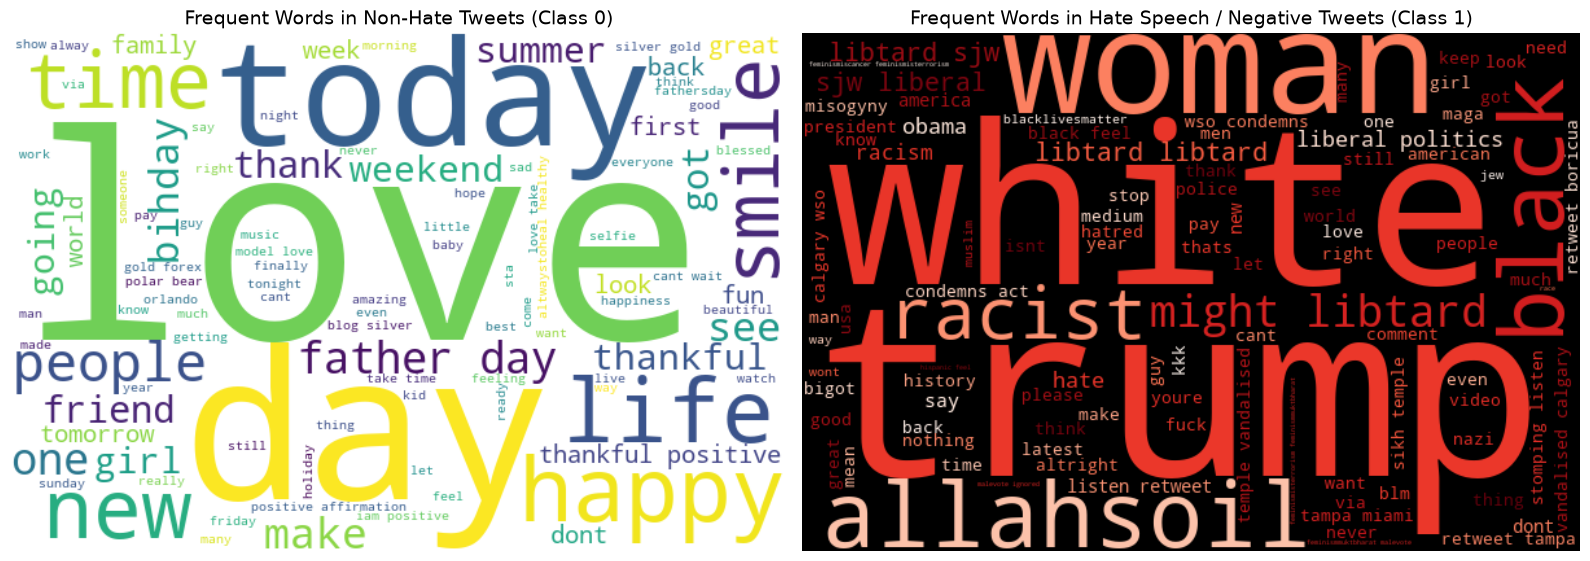

In [10]:
# ============================================================
# STEP 5: VISUALIZE MOST FREQUENT WORDS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Non-Hate Word Cloud (Class 0)
normal_text = " ".join(df[df[TARGET_COLUMN] == 0]["clean_tweet"])
wc_normal = WordCloud(width=600, height=400, background_color="white", max_words=100).generate(normal_text)
axes[0].imshow(wc_normal, interpolation="bilinear")
axes[0].set_title("Frequent Words in Non-Hate Tweets (Class 0)", fontsize=14)
axes[0].axis("off")

# Hate Speech Word Cloud (Class 1)
hate_text = " ".join(df[df[TARGET_COLUMN] == 1]["clean_tweet"])
wc_hate = WordCloud(width=600, height=400, background_color="black", colormap="Reds", max_words=100).generate(hate_text)
axes[1].imshow(wc_hate, interpolation="bilinear")
axes[1].set_title("Frequent Words in Hate Speech / Negative Tweets (Class 1)", fontsize=14)
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# STEP 6: FEATURE EXTRACTION & TRAIN-TEST SPLIT
# ============================================================
X = df["clean_tweet"]
y = df[TARGET_COLUMN]

# Train-Test Split (Stratify ensures the 93:7 ratio is maintained in both sets)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# TF-IDF Feature Extractor
tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = tfidf_vectorizer.fit_transform(X_train_raw)
X_test = tfidf_vectorizer.transform(X_test_raw)

print(f"Training Samples: {X_train.shape[0]} | Testing Samples: {X_test.shape[0]}")
print(f"Vocabulary Size: {X_train.shape[1]} features")

Training Samples: 25569 | Testing Samples: 6393
Vocabulary Size: 10000 features


In [12]:
# ============================================================
# STEP 7: TRAIN CLASSIFIERS
# ============================================================
# We use class_weight='balanced' to prevent bias against the 7% minority class
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.1),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=20, random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=42)
}

results = []
trained_models = {}

for model_name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    trained_models[model_name] = model
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=1, zero_division=0)
    
    results.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision (Class 1)": round(prec, 4),
        "Recall (Class 1)": round(rec, 4),
        "F1-Score (Class 1)": round(f1, 4)
    })

# Performance Summary Table
performance_df = pd.DataFrame(results).sort_values(by="F1-Score (Class 1)", ascending=False)
display(performance_df)

,Model,Accuracy,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
3,Random Forest,0.9568,0.6911,0.6942,0.6927
1,Multinomial Naive Bayes,0.9600,0.8692,0.5045,0.6384
0,Logistic Regression,0.9318,0.5087,0.7812,0.6162
2,Decision Tree,0.9401,0.6006,0.4330,0.5032


Detailed Classification Report for Random Forest:

                 precision    recall  f1-score   support

   Non-Hate (0)       0.98      0.98      0.98      5945
Hate Speech (1)       0.69      0.69      0.69       448

       accuracy                           0.96      6393
      macro avg       0.83      0.84      0.83      6393
   weighted avg       0.96      0.96      0.96      6393



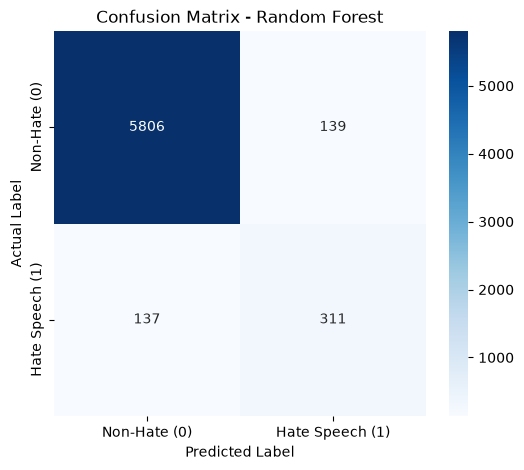

In [13]:
# ============================================================
# STEP 8: DETAILED EVALUATION OF THE BEST MODEL
# ============================================================
best_model_name = performance_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Detailed Classification Report for {best_model_name}:\n")
y_pred_best = best_model.predict(X_test)
print(classification_report(y_test, y_pred_best, target_names=["Non-Hate (0)", "Hate Speech (1)"]))

# Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Non-Hate (0)", "Hate Speech (1)"], 
            yticklabels=["Non-Hate (0)", "Hate Speech (1)"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [14]:
# ============================================================
# STEP 9: REAL-TIME PREDICTION FUNCTION
# ============================================================
def predict_sentiment(sample_text, model=best_model, vectorizer=tfidf_vectorizer):
    # Preprocess the raw input
    cleaned_text = clean_tweet(sample_text)
    
    # Vectorize
    vectorized_input = vectorizer.transform([cleaned_text])
    
    # Predict numerical label and probabilities
    prediction = model.predict(vectorized_input)[0]
    
    confidence = None
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(vectorized_input)[0]
        confidence = round(probabilities[prediction] * 100, 2)
    
    sentiment_label = LABEL_MAPPING.get(prediction, "Unknown")
    
    return {
        "Original Tweet": sample_text,
        "Cleaned Tweet": cleaned_text,
        "Predicted Class": int(prediction),
        "Sentiment": sentiment_label,
        "Confidence (%)": confidence
    }

# Test with examples
test_samples = [
    "@user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed",
    "@user #sikh #temple vandalised in #calgary, #wso condemns act",
    "i love you so much! what a beautiful sunny morning #happy #grateful"
]

for sample in test_samples:
    res = predict_sentiment(sample)
    print(f"Tweet     : {res['Original Tweet']}")
    print(f"Predicted : {res['Sentiment']} (Class {res['Predicted Class']}) | Confidence: {res['Confidence (%)']}%\n")

Tweet     : @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed
Predicted : Non-Hate / Positive-Neutral (Class 0) | Confidence: 98.0%

Tweet     : @user #sikh #temple vandalised in #calgary, #wso condemns act
Predicted : Hate Speech / Negative (Class 1) | Confidence: 100.0%

Tweet     : i love you so much! what a beautiful sunny morning #happy #grateful
Predicted : Non-Hate / Positive-Neutral (Class 0) | Confidence: 100.0%



In [15]:
# ============================================================
# STEP 10: PERSIST MODEL & VECTORIZER
# ============================================================
joblib.dump(best_model, "twitter_sentiment_model.pkl")
joblib.dump(tfidf_vectorizer, "tfidf_vectorizer.pkl")
print("Model and vectorizer saved successfully to disk.")

Model and vectorizer saved successfully to disk.
